# 纯 Python 求解电路并进行脉冲编码

本 notebook 不启动 LTspice，而是根据仓库中的 NbOx 振荡器、突触、TIA 和电平移位参数，使用一阶状态方程近似计算 `final_out`。

运放被近似为理想运放，因此波形不保证与 LTspice 逐点相同；模型的目标是保留阈值振荡、突触状态和最终 spike 编码。

## 1. 从 STEMNIST 样本生成 PCTRL PWL

In [9]:
from dataclasses import dataclass
from math import exp, log
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np


DURATION = 2.0
FRAME_COUNT = 240
FRAME_DT = DURATION / FRAME_COUNT


def find_repository_root():
    """Locate the repository when Jupyter starts in it or its parent."""
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "neurophic_system_model_var_Rload").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "未找到 neurophic_system_model_var_Rload 目录，"
        "请从仓库根目录启动 Jupyter"
    )


REPOSITORY_ROOT = find_repository_root()
PROJECT_DIR = REPOSITORY_ROOT / "neurophic_system_model_var_Rload"

H5_PATH = Path(
    r"C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST"
    r"\first_stage\STEMNIST\extracted"
    r"\STEMNIST Dataset\RawCharacters\AT_A_1.h5"
)
ROW = 9
COLUMN = 6

In [10]:
def write_pressure_pwl(
    pressure_sequence,
    output_path,
    duration=DURATION,
    edge_time=1e-9,
):
    """Write a 240-frame pressure sequence as an LTspice-style PWL."""
    pressure_sequence = np.asarray(pressure_sequence, dtype=np.float64)
    if pressure_sequence.ndim != 1:
        raise ValueError("压力序列必须是一维数组")
    if len(pressure_sequence) != FRAME_COUNT:
        raise ValueError(
            f"STEMNIST 样本应包含 {FRAME_COUNT} 帧，"
            f"实际为 {len(pressure_sequence)} 帧"
        )

    pressure_sequence = np.clip(pressure_sequence, 0.0, 255.0)
    frame_dt = duration / len(pressure_sequence)
    edge_time = min(edge_time, frame_dt / 1000.0)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with output_path.open("w", encoding="ascii", newline="\n") as file:
        file.write(f"0 {pressure_sequence[0]:.9g}\n")
        for frame_index, pressure_value in enumerate(pressure_sequence):
            frame_end = (frame_index + 1) * frame_dt
            file.write(
                f"{frame_end - edge_time:.12g} {pressure_value:.9g}\n"
            )
            if frame_index + 1 < len(pressure_sequence):
                next_pressure = pressure_sequence[frame_index + 1]
                file.write(f"{frame_end:.12g} {next_pressure:.9g}\n")
        file.write(f"{duration:.12g} {pressure_sequence[-1]:.9g}\n")


if not H5_PATH.is_file():
    raise FileNotFoundError(f"找不到 STEMNIST 样本：{H5_PATH}")

with h5py.File(H5_PATH, "r") as h5_file:
    pressure_data = h5_file["pressure_data"][...]

if pressure_data.shape != (FRAME_COUNT, 16, 16):
    raise ValueError(f"压力数组形状错误：{pressure_data.shape}")

taxel_pressure = pressure_data[:, ROW, COLUMN]
pctrl_path = (
    PROJECT_DIR
    / "PCTRL"
    / f"PCTRL_AT_A_1_r{ROW:02d}_c{COLUMN:02d}.pwl"
)
write_pressure_pwl(taxel_pressure, pctrl_path)

print(f"PWL 生成完成：{pctrl_path}")
print(f"压力范围：{taxel_pressure.min():.6g} ~ {taxel_pressure.max():.6g}")

PWL 生成完成：C:\Users\Fortyfour\Desktop\SystemOut_SpikeEncoding\neurophic_system_model_var_Rload\PCTRL\PCTRL_AT_A_1_r09_c06.pwl
压力范围：80 ~ 212


## 2. 纯 Python 电路状态方程

每个时间步对一阶 RC 状态使用指数解更新，比显式 Euler 更稳定。NbOx 比较器使用 `VH/VL` 滞回状态机近似；TIA 和移位运放使用理想运放近似。

In [11]:
@dataclass(frozen=True)
class SystemModelParameters:
    duration: float = 2.0
    dt: float = 20e-6

    # NbOx oscillators
    vin_u1: float = 2.5
    vh: float = 1.676
    vl: float = 1.127
    rin_nbox: float = 89213.44
    rme_nbox: float = 806.0
    cparal: float = 1e-6
    u2_rload: float = 10e3

    # SYNAPSE_ADV_V2
    synapse_vth: float = 0.679973290013
    synapse_vnorm: float = 2.0
    synapse_pdrive: float = 1.1281797291
    ron1: float = 651321.797132
    roff1: float = 58783.4118027
    ron2: float = 6453.3547737
    roff2: float = 7225.92691131
    ron3: float = 54391.4170977
    roff3: float = 22092.0764053
    g11: float = 0.000663574393119
    g12: float = 0.00122698089109
    g13: float = 4.42225017007e-05
    g23: float = 0.000671314326731
    gv: float = 6.561726644e-06
    synapse_vds: float = 1.0

    # TIA and level shift
    rf1: float = 2.5e3
    cf1: float = 10e-9
    vref: float = 0.75
    rin2: float = 10e3
    rf2: float = 10e3
    negative_rail: float = -5.0
    positive_rail: float = 5.0


def load_pressure_pwl(pwl_path, duration, dt):
    """Sample an LTspice-style two-column PWL on a uniform time grid."""
    pwl_path = Path(pwl_path)
    if not pwl_path.is_file():
        raise FileNotFoundError(f"PCTRL 文件不存在：{pwl_path.resolve()}")
    if duration <= 0.0 or dt <= 0.0:
        raise ValueError("duration 和 dt 必须大于 0")

    pwl = np.loadtxt(pwl_path, dtype=np.float64)
    if pwl.ndim != 2 or pwl.shape[1] != 2:
        raise ValueError("PCTRL PWL 必须是两列：time value")
    if not np.all(np.isfinite(pwl)):
        raise ValueError("PCTRL PWL 包含 NaN 或无穷大")
    if np.any(np.diff(pwl[:, 0]) < 0.0):
        raise ValueError("PCTRL PWL 时间必须单调不减")

    step_count = int(round(duration / dt))
    time = np.linspace(0.0, duration, step_count + 1, dtype=np.float64)
    actual_dt = time[1] - time[0]
    pressure = np.interp(time, pwl[:, 0], pwl[:, 1])
    return time, pressure, actual_dt

In [12]:
def _advance_nbox_oscillator(
    voltage,
    high_resistance,
    input_voltage,
    load_resistance,
    dt,
    par,
):
    """Advance one RC-NbOx oscillator, resolving a switch inside the step."""
    nbox_resistance = (
        par.rin_nbox if high_resistance else par.rme_nbox
    )
    target = (
        input_voltage
        * nbox_resistance
        / (load_resistance + nbox_resistance)
    )
    tau = par.cparal / (
        1.0 / load_resistance + 1.0 / nbox_resistance
    )
    next_voltage = target + (voltage - target) * exp(-dt / tau)

    crossed_high = high_resistance and next_voltage >= par.vh
    crossed_low = not high_resistance and next_voltage <= par.vl
    if not (crossed_high or crossed_low):
        return next_voltage, high_resistance

    # Locate the threshold crossing analytically and use the remaining
    # fraction of this time step in the new resistance state.
    threshold = par.vh if high_resistance else par.vl
    ratio = (threshold - target) / (voltage - target)
    crossing_time = -tau * log(ratio)
    remaining_time = max(dt - crossing_time, 0.0)
    high_resistance = not high_resistance

    nbox_resistance = (
        par.rin_nbox if high_resistance else par.rme_nbox
    )
    target = (
        input_voltage
        * nbox_resistance
        / (load_resistance + nbox_resistance)
    )
    tau = par.cparal / (
        1.0 / load_resistance + 1.0 / nbox_resistance
    )
    next_voltage = target + (threshold - target) * exp(
        -remaining_time / tau
    )
    return next_voltage, high_resistance


def simulate_system_python(pwl_path, parameters=None):
    """
    Simulate the repository circuit without LTspice.

    Returns a dictionary containing time, intermediate nodes and final_out.
    """
    par = parameters or SystemModelParameters()
    time, pressure, dt = load_pressure_pwl(
        pwl_path,
        duration=par.duration,
        dt=par.dt,
    )

    # PCTRL <= 75: nearly open; otherwise 900k/(PCTRL-75), limited to 5k..1T.
    u1_rload = np.full(time.shape, 1e12, dtype=np.float64)
    active_pressure = pressure > 75.0
    u1_rload[active_pressure] = np.clip(
        900e3 / np.maximum(pressure[active_pressure] - 75.0, 1e-6),
        5e3,
        1e12,
    )

    point_count = len(time)
    u1_output = np.zeros(point_count, dtype=np.float64)
    x1 = np.zeros(point_count, dtype=np.float64)
    x2 = np.zeros(point_count, dtype=np.float64)
    x3 = np.zeros(point_count, dtype=np.float64)
    synapse_current = np.zeros(point_count, dtype=np.float64)
    vtia = np.zeros(point_count, dtype=np.float64)
    vdrive = np.zeros(point_count, dtype=np.float64)
    final_out = np.zeros(point_count, dtype=np.float64)

    u1_high_resistance = True
    u2_high_resistance = True
    state_x1 = 0.0
    state_x2 = 0.0
    state_x3 = 0.0

    # Exact one-step decay factors for the fixed first-order states.
    x1_on_decay = exp(-dt / (par.ron1 * 1e-6))
    x1_off_decay = exp(-dt / (par.roff1 * 1e-6))
    x2_on_decay = exp(-dt / (par.ron2 * 1e-6))
    x2_off_decay = exp(-dt / (par.roff2 * 1e-6))
    x3_on_decay = exp(-dt / (par.ron3 * 1e-6))
    x3_off_decay = exp(-dt / (par.roff3 * 1e-6))
    tia_decay = exp(-dt / (par.rf1 * par.cf1))

    for index in range(1, point_count):
        # U1: pressure-controlled RC-NbOx oscillator.
        load = u1_rload[index - 1]
        u1_value, u1_high_resistance = _advance_nbox_oscillator(
            voltage=u1_output[index - 1],
            high_resistance=u1_high_resistance,
            input_voltage=par.vin_u1,
            load_resistance=load,
            dt=dt,
            par=par,
        )
        u1_output[index] = u1_value

        # Three-state SYNAPSE_ADV_V2 model.
        normalized_gate = max(
            (u1_value - par.synapse_vth)
            / (par.synapse_vnorm - par.synapse_vth),
            0.0,
        ) ** par.synapse_pdrive

        if u1_value > par.synapse_vth:
            state_x1 = normalized_gate + (
                state_x1 - normalized_gate
            ) * x1_on_decay
            state_x2 = normalized_gate + (
                state_x2 - normalized_gate
            ) * x2_on_decay
            state_x3 = normalized_gate + (
                state_x3 - normalized_gate
            ) * x3_on_decay
        else:
            state_x1 *= x1_off_decay
            state_x2 *= x2_off_decay
            state_x3 *= x3_off_decay

        x1[index] = state_x1
        x2[index] = state_x2
        x3[index] = state_x3

        conductance = max(
            par.g11 * state_x1 * state_x1
            + par.g12 * state_x1 * state_x2
            + par.g13 * state_x1 * state_x3
            + par.g23 * state_x2 * state_x3
            + par.gv * normalized_gate,
            0.0,
        )
        current = par.synapse_vds * conductance
        synapse_current[index] = current

        # Idealized TIA: Rf1 || Cf1, followed by an inverting level shift.
        tia_target = -par.rf1 * current
        tia_value = tia_target + (
            vtia[index - 1] - tia_target
        ) * tia_decay
        tia_value = min(
            max(tia_value, par.negative_rail),
            par.positive_rail,
        )
        vtia[index] = tia_value

        gain = par.rf2 / par.rin2
        drive = (1.0 + gain) * par.vref - gain * tia_value
        drive = min(
            max(drive, par.negative_rail),
            par.positive_rail,
        )
        vdrive[index] = drive

        # U2: fixed-load RC-NbOx oscillator producing final_out.
        u2_value, u2_high_resistance = _advance_nbox_oscillator(
            voltage=final_out[index - 1],
            high_resistance=u2_high_resistance,
            input_voltage=drive,
            load_resistance=par.u2_rload,
            dt=dt,
            par=par,
        )
        final_out[index] = u2_value

    return {
        "time": time,
        "pressure": pressure,
        "u1_rload": u1_rload,
        "u1_output": u1_output,
        "synapse_x1": x1,
        "synapse_x2": x2,
        "synapse_x3": x3,
        "synapse_current": synapse_current,
        "vtia": vtia,
        "vdrive": vdrive,
        "final_out": final_out,
    }

In [13]:
model_parameters = SystemModelParameters(
    duration=DURATION,
    dt=20e-6,
)
signals = simulate_system_python(pctrl_path, model_parameters)

time = signals["time"]
final_out = signals["final_out"]

print(f"采样点数：{len(time)}")
print(f"时间范围：{time[0]:.6g} ~ {time[-1]:.6g} s")
print(
    f"final_out 范围："
    f"{final_out.min():.6g} ~ {final_out.max():.6g} V"
)

采样点数：100001
时间范围：0 ~ 2 s
final_out 范围：0 ~ 1.6759 V


## 3. 检测 final_out 中的 spike 时刻

In [14]:
def detect_u2_spike_times(
    time,
    final_out,
    v_arm=1.55,
    v_fire=1.25,
    refractory=0.5e-3,
):
    """Detect armed falling crossings in the U2 final_out waveform."""
    time = np.asarray(time, dtype=np.float64)
    final_out = np.asarray(final_out, dtype=np.float64)
    if time.ndim != 1 or final_out.ndim != 1:
        raise ValueError("time 和 final_out 必须是一维数组")
    if time.shape != final_out.shape:
        raise ValueError("time 和 final_out 形状必须相同")

    armed = False
    last_spike_time = -np.inf
    spike_times = []

    for index in range(1, len(time)):
        if final_out[index] >= v_arm:
            armed = True

        falling_crossing = (
            final_out[index - 1] > v_fire
            and final_out[index] <= v_fire
        )
        outside_refractory = (
            time[index] - last_spike_time >= refractory
        )

        if armed and falling_crossing and outside_refractory:
            spike_times.append(time[index])
            last_spike_time = time[index]
            armed = False

    return np.asarray(spike_times, dtype=np.float64)


spike_times = detect_u2_spike_times(time, final_out)
print(f"检测到 {len(spike_times)} 个 spike")
print("spike_times (s):", spike_times)

检测到 5 个 spike
spike_times (s): [1.68292 1.69568 1.7083  1.72192 1.73892]


## 4. 将 spike 时刻分箱为 240 帧编码

In [15]:
def bin_spike_times(
    spike_times,
    time_steps=FRAME_COUNT,
    duration=DURATION,
    binary=True,
):
    """Map continuous spike times to fixed-width temporal bins."""
    spike_times = np.asarray(spike_times, dtype=np.float64)
    if spike_times.ndim != 1:
        raise ValueError("spike_times 必须是一维数组")
    if time_steps <= 0 or duration <= 0.0:
        raise ValueError("time_steps 和 duration 必须大于 0")

    counts = np.zeros(time_steps, dtype=np.uint16)
    bin_dt = duration / time_steps
    valid_spikes = spike_times[
        (spike_times >= 0.0) & (spike_times < duration)
    ]
    indices = np.floor(valid_spikes / bin_dt).astype(np.int64)
    np.add.at(counts, indices, 1)

    if binary:
        return (counts > 0).astype(np.uint8)
    return counts


spikes = bin_spike_times(
    spike_times,
    time_steps=FRAME_COUNT,
    duration=DURATION,
    binary=True,
)
active_bins = np.flatnonzero(spikes)
print("spikes shape:", spikes.shape)
print("值为 1 的分箱索引：", active_bins)
spikes

spikes shape: (240,)
值为 1 的分箱索引： [201 203 204 206 208]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=uint8)

## 5. 绘制 final_out 和编码后的 spikes

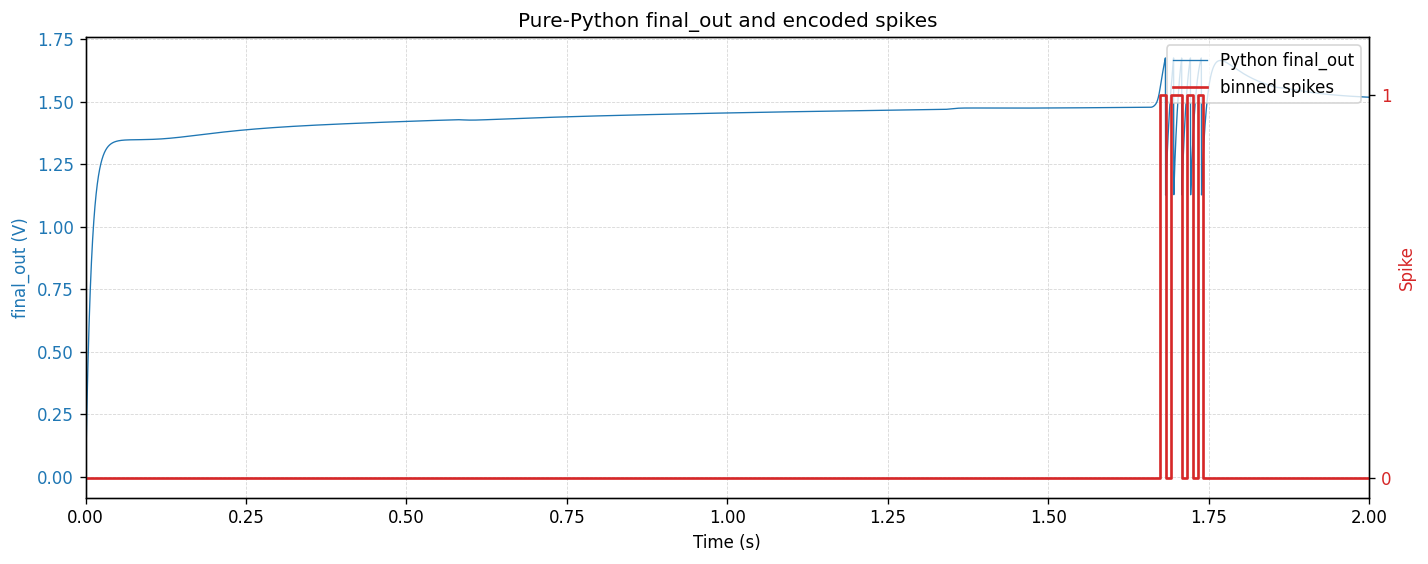

In [16]:
spike_bin_edges = np.linspace(0.0, DURATION, len(spikes) + 1)
spikes_for_plot = np.r_[spikes, spikes[-1]]

fig, voltage_ax = plt.subplots(figsize=(12, 4.8), dpi=120)
voltage_line, = voltage_ax.plot(
    time,
    final_out,
    color="#1f77b4",
    linewidth=0.8,
    label="Python final_out",
)
voltage_ax.set_xlabel("Time (s)")
voltage_ax.set_ylabel("final_out (V)", color="#1f77b4")
voltage_ax.tick_params(axis="y", labelcolor="#1f77b4")
voltage_ax.set_xlim(time[0], time[-1])
voltage_ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

spike_ax = voltage_ax.twinx()
spike_line, = spike_ax.step(
    spike_bin_edges,
    spikes_for_plot,
    where="post",
    color="#d62728",
    linewidth=1.6,
    label="binned spikes",
)
spike_ax.set_ylabel("Spike", color="#d62728")
spike_ax.set_ylim(-0.05, 1.15)
spike_ax.set_yticks([0, 1])
spike_ax.tick_params(axis="y", labelcolor="#d62728")

voltage_ax.legend(
    handles=[voltage_line, spike_line],
    loc="upper right",
)
voltage_ax.set_title("Pure-Python final_out and encoded spikes")
fig.tight_layout()
plt.show()